# Pneumonia Detection from Chest X-Rays
### Deep Learning — Final Project (99006)

---

## 1. Introduction

Pneumonia is an acute respiratory infection affecting millions of people worldwide and is a leading cause of mortality in children under five. Timely and accurate diagnosis is critical, yet in many healthcare settings trained radiologists are scarce. Chest X-ray imaging is the standard first-line diagnostic tool: a radiologist examines the film for characteristic opacification patterns that distinguish bacterial or viral pneumonia from a healthy lung.

Automating this diagnosis with a machine-learning system could reduce diagnostic delay, lower costs, and extend quality care to under-resourced facilities. The seminal work by Rajpurkar et al. (CheXNet, 2017) showed that a deep convolutional network trained on 100 000 chest X-rays can match radiologist-level performance on the 14-class NIH ChestX-ray14 benchmark. More recently, Kermany et al. (Cell, 2018) released the Guangzhou pediatric dataset we use here and demonstrated that a transfer-learned Inception network reaches >90% accuracy at the binary pneumonia detection task.

In this project we build a complete classification pipeline from scratch, deliberately avoiding any open-source implementations. We train three increasingly powerful models:

1. A **linear SVM** classifier operating on raw pixel features — an interpretable baseline that quantifies what a purely linear decision boundary can achieve.
2. A **two-layer convolutional network** that learns local texture features relevant to lung opacification.
3. A **deep convolutional network** with batch normalization, max-pooling, and dropout, tuned for best performance.

The progression lets us measure the concrete accuracy gain each level of representation adds and understand where the remaining errors come from.

---

## 2. Dataset

The dataset is the **Chest X-Ray Images (Pneumonia)** collection released by Kermany et al. (2018) and hosted on Kaggle. It contains **5 863 JPEG chest X-ray images** from pediatric patients (aged 1–5 years) at the Guangzhou Women and Children's Medical Center.

**Categories:**
- `NORMAL` — clear lungs, no areas of abnormal opacification.
- `PNEUMONIA` — focal lobar consolidation (bacterial) or diffuse interstitial pattern (viral).

**Collection and labeling process:** All radiographs were screened for quality by removing low-quality or unreadable scans. Diagnoses were graded independently by two expert physicians; the evaluation set was additionally reviewed by a third expert to account for grading error.

**Dataset structure:** The archive ships with three pre-defined splits. The official validation folder holds only 16 images (8 per class), which is too few for reliable hyperparameter tuning. We therefore carve a **stratified 15 % validation set from the training data** (keeping the original 16 images for a sanity reference) and leave the 624-image test set untouched.

| Split | NORMAL | PNEUMONIA | Total |
|-------|--------|-----------|-------|
| train (after re-split) | 1 140 | 3 294 | 4 434 |
| val (re-split)         |   201 |   581 |   782 |
| test (original)        |   234 |   390 |   624 |

Note the **1 : 2.9 class imbalance** — pneumonia scans are nearly three times more common. We account for this by (a) using class-weighted loss during CNN training and (b) reporting per-class precision, recall, and F1 alongside raw accuracy.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_BASE = '/content/drive/MyDrive/chest_xray'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# --- Dataset discovery and quality-control screening ---
import data_utils as du
import metrics
import matplotlib.pyplot as plt

DATASET_BASE = '/content/drive/MyDrive/chest_xray'   # folder containing the chest_xray archive

data_root = du.find_dataset_root(DATASET_BASE)
print('Dataset root:', data_root)

# Load all three splits and run quality-control screening.
raw_train, qc_train = du.screen_images(du.list_labeled_images(data_root + '/train'))
raw_val,  qc_val  = du.screen_images(du.list_labeled_images(data_root + '/val'))
raw_test, qc_test = du.screen_images(du.list_labeled_images(data_root + '/test'))

print('\nQC report (unreadable / too-small files removed):')
for name, kept, rep in [('train', raw_train, qc_train),
                         ('val',   raw_val,   qc_val),
                         ('test',  raw_test,  qc_test)]:
    print(f'  {name}: kept {rep["kept"]} / {rep["total"]}  '
          f'(removed {rep["removed_unreadable"]} unreadable, '
          f'{rep["removed_too_small"]} too-small)')

Dataset root: /content/drive/MyDrive/chest_xray

QC report (unreadable / too-small files removed):
  train: kept 5216 / 5216  (removed 0 unreadable, 0 too-small)
  val: kept 16 / 16  (removed 0 unreadable, 0 too-small)
  test: kept 624 / 624  (removed 0 unreadable, 0 too-small)


In [3]:
# --- Stratified re-split of the training data ---
train_items, val_items = du.make_stratified_val_split(raw_train, val_fraction=0.15, seed=0)
test_items = raw_test

print('Final splits:')
for name, items in [('train', train_items), ('val', val_items), ('test', test_items)]:
    counts = du.count_by_class(items)
    print(f'  {name:5s}: NORMAL={counts["NORMAL"]:4d}  PNEUMONIA={counts["PNEUMONIA"]:4d}  total={len(items):4d}')

Final splits:
  train: NORMAL=1140  PNEUMONIA=3294  total=4434
  val  : NORMAL= 201  PNEUMONIA= 581  total= 782
  test : NORMAL= 234  PNEUMONIA= 390  total= 624


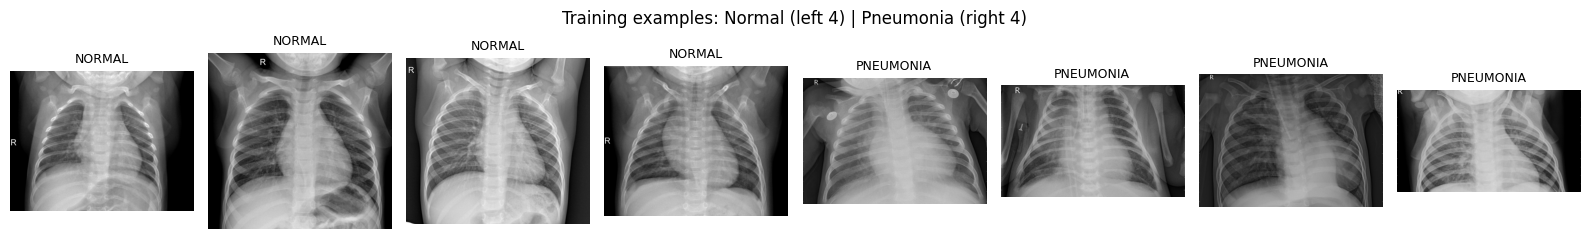

In [4]:
# --- EDA: example images ---
# Show 4 normal and 4 pneumonia samples from the training set.
normal_samples = [(p, l) for p, l in train_items if l == 0][:4]
pneu_samples   = [(p, l) for p, l in train_items if l == 1][:4]
fig = metrics.show_examples(normal_samples + pneu_samples, n=8,
                             title='Training examples: Normal (left 4) | Pneumonia (right 4)')
plt.show()

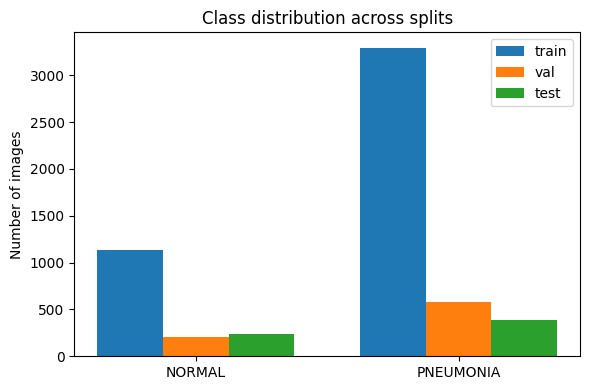

In [5]:
# --- EDA: class distribution bar chart ---
from data_utils import CLASS_NAMES
import numpy as np

splits = {'train': train_items, 'val': val_items, 'test': test_items}
x = np.arange(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(6, 4))
for i, (split_name, items) in enumerate(splits.items()):
    counts = du.count_by_class(items)
    ax.bar(x + i * width, [counts[c] for c in CLASS_NAMES], width, label=split_name)
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Number of images')
ax.set_title('Class distribution across splits')
ax.legend()
plt.tight_layout()
plt.show()

---

## 3. Method

### 3.1 Preprocessing

All models share a common image preprocessing pipeline:

- **Grayscale conversion** — X-rays are single-channel images; dropping color channels reduces dimensionality and removes any color-tinting artifacts from different scanner manufacturers.
- **Resize** — images are rescaled to a fixed square resolution. We use **64 × 64** for the SVM (flattened to 4 096 features) and **128 × 128** for the CNNs, balancing spatial detail against training speed.
- **Mean normalization** — pixels are divided by 255 to put them in [0, 1]. For the CNNs we additionally subtract the per-channel training mean and divide by the training standard deviation (estimated from a random sample of 500 training images).
- **Augmentation (train only)** — horizontal flips, ±10° rotations, and random-crop zooms between 85–100 %. These are label-preserving operations for chest X-rays and help reduce overfitting.

### 3.2 Linear SVM Baseline

We implement the **multiclass SVM** (Weston & Watkins formulation) from scratch in NumPy using the hinge loss:

$$L = \frac{1}{N} \sum_i \sum_{j \ne y_i} \max\left(0,\; s_j - s_{y_i} + \Delta\right) + R(W)$$

where $\Delta = 1$ is the margin, $s = Wx$ are the class scores, and $R(W)$ is either L2 ($\lambda \|W\|_F^2$) or L1 ($\lambda \|W\|_1$) regularization. We develop the gradient in two stages:

1. `svm_loss_naive` — explicit loops over examples and classes; transparent but slow.
2. `svm_loss_vectorized` — matrix operations that produce identical results.

We verify correctness by checking (a) naive == vectorized and (b) the analytic gradient matches a central-difference numerical estimate within relative error 10⁻⁹.

The `LinearClassifier` trains with **mini-batch SGD** (batch size 200, 1 500 iterations). The bias is handled with the bias trick (append a constant 1 to each input). Weights are initialised with small random values (σ = 0.001).

### 3.3 Two-Layer Convolutional Network

```
Input (1 × 128 × 128)
  → Conv2d(16 filters, 3×3, pad 1) → ReLU → MaxPool2d(2)
  → Flatten → Linear(hidden_dim=256) → ReLU
  → Linear(2)
```

One convolutional stage extracts local edge and texture patterns; the FC layers combine them into a global prediction. Trained with **Adam** (lr = 1e-3) and cross-entropy loss.

**Sanity check:** before full training we verify the network can overfit a 32-sample batch to 100 % training accuracy, confirming that gradients flow correctly.

### 3.4 Deep Convolutional Network

```
Input (1 × 128 × 128)
  → [Conv2d(32, 3×3) → BatchNorm2d → ReLU → MaxPool2d(2)]  # block 1
  → [Conv2d(64, 3×3) → BatchNorm2d → ReLU → MaxPool2d(2)]  # block 2
  → [Conv2d(128,3×3) → BatchNorm2d → ReLU → MaxPool2d(2)]  # block 3
  → AdaptiveAvgPool2d(4×4)
  → Flatten → Linear(256) → ReLU → Dropout(0.5) → Linear(2)
```

**Batch normalization** after every convolution normalizes the activations at each layer, which (a) allows higher learning rates, (b) acts as implicit regularization, and (c) reduces sensitivity to weight initialization. **Adaptive average pooling** before the FC head means the network works with any input resolution without changing the classifier size — useful when we later increase resolution on Colab.

Trained with **Adam** (lr = 1e-3), **class-weighted cross-entropy** (NORMAL weight ≈ 1.94, PNEUMONIA weight ≈ 0.67) to correct for the 1:2.9 class imbalance, and **dropout = 0.5** in the head.

---

## 4. Experiments

### 4.1 Gradient and loss sanity checks

In [6]:
# Verify that the naive and vectorized SVM losses match, and that
# the analytic gradient is close to the numerical estimate.
import numpy as np
import linear_svm as svm

rng = np.random.RandomState(42)
N, D, C = 60, 200, 2
X_check = rng.randn(N, D).astype(np.float64)
y_check = rng.randint(C, size=N)
W_check = (0.01 * rng.randn(D, C)).astype(np.float64)

for reg_type in ['l2', 'l1']:
    l_n, g_n = svm.svm_loss_naive(W_check, X_check, y_check, reg=0.05, reg_type=reg_type)
    l_v, g_v = svm.svm_loss_vectorized(W_check, X_check, y_check, reg=0.05, reg_type=reg_type)
    loss_diff = abs(l_n - l_v)
    grad_diff = float(np.abs(g_n - g_v).max())

    loss_fn = lambda W: svm.svm_loss_vectorized(W, X_check, y_check, reg=0.05, reg_type=reg_type)[0]
    checks = svm.numeric_gradient(loss_fn, W_check.copy(), num_checks=8)
    worst_rel = max(
        abs(g_v[ix] - num) / (abs(g_v[ix]) + abs(num) + 1e-12)
        for ix, num in checks
    )
    print(f'[{reg_type}] naive==vec loss diff: {loss_diff:.2e}  grad diff: {grad_diff:.2e}')
    print(f'       worst analytic/numeric relative error: {worst_rel:.2e}')

print('\nAll checks passed — proceeding to full training.')

[l2] naive==vec loss diff: 0.00e+00  grad diff: 0.00e+00
       worst analytic/numeric relative error: 7.33e-11
[l1] naive==vec loss diff: 0.00e+00  grad diff: 0.00e+00
       worst analytic/numeric relative error: 2.38e-10

All checks passed — proceeding to full training.


### 4.2 SVM — Preprocessing and feature loading

In [7]:
# Load the SVM feature arrays (64×64 grayscale, flattened and mean-centred).
SVM_IMG_SIZE = 64

print('Loading SVM feature matrices...')
X_train, y_train = du.load_images_as_arrays(train_items, image_size=SVM_IMG_SIZE)
X_val,   y_val   = du.load_images_as_arrays(val_items,   image_size=SVM_IMG_SIZE)
X_test,  y_test  = du.load_images_as_arrays(test_items,  image_size=SVM_IMG_SIZE)

# Mean-centre using training statistics only (never touch test stats during training).
train_mean = X_train.mean(axis=0, keepdims=True)
X_train -= train_mean
X_val   -= train_mean
X_test  -= train_mean

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

Loading SVM feature matrices...
X_train: (4434, 4096)  X_val: (782, 4096)  X_test: (624, 4096)


### 4.3 SVM — Hyperparameter sweep (L2 regularization)

In [8]:
# Grid search over learning rate and regularization strength.
# We use L2 regularization first, then compare L1 below.

learning_rates = [1e-1, 5e-2, 1e-2]
reg_strengths  = [1e-2, 1e-3, 1e-4]

best_val_acc = 0.0
best_params  = {}
results_l2   = {}

print('L2 sweep (lr × reg):')
for lr in learning_rates:
    for reg in reg_strengths:
        clf = svm.LinearClassifier()
        clf.train(X_train, y_train, learning_rate=lr, reg=reg, reg_type='l2',
                  num_iters=1500, batch_size=200, seed=0)
        val_acc = metrics.accuracy(clf.predict(X_val), y_val)
        results_l2[(lr, reg)] = val_acc
        marker = ' <-- best' if val_acc > best_val_acc else ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params  = {'lr': lr, 'reg': reg, 'reg_type': 'l2'}
        print(f'  lr={lr:.0e}  reg={reg:.0e}  val_acc={val_acc:.4f}{marker}')

print(f'\nBest L2 params: {best_params}  (val_acc={best_val_acc:.4f})')

L2 sweep (lr × reg):
  lr=1e-01  reg=1e-02  val_acc=0.9527 <-- best
  lr=1e-01  reg=1e-03  val_acc=0.9591 <-- best
  lr=1e-01  reg=1e-04  val_acc=0.9591
  lr=5e-02  reg=1e-02  val_acc=0.9552
  lr=5e-02  reg=1e-03  val_acc=0.9578
  lr=5e-02  reg=1e-04  val_acc=0.9578
  lr=1e-02  reg=1e-02  val_acc=0.9540
  lr=1e-02  reg=1e-03  val_acc=0.9552
  lr=1e-02  reg=1e-04  val_acc=0.9552

Best L2 params: {'lr': 0.1, 'reg': 0.001, 'reg_type': 'l2'}  (val_acc=0.9591)


### 4.4 SVM — L1 vs L2 regularization comparison

In [9]:
# Train L1 and L2 SVMs with matched hyperparameters and compare.

results_reg = {}
for reg_type in ['l2', 'l1']:
    best_acc_rt = 0.0
    best_clf_rt = None
    for reg in reg_strengths:
        clf = svm.LinearClassifier()
        clf.train(X_train, y_train, learning_rate=best_params['lr'], reg=reg,
                  reg_type=reg_type, num_iters=1500, batch_size=200, seed=0)
        val_acc = metrics.accuracy(clf.predict(X_val), y_val)
        if val_acc > best_acc_rt:
            best_acc_rt = val_acc
            best_clf_rt = clf
    results_reg[reg_type] = (best_clf_rt, best_acc_rt)
    print(f'{reg_type.upper()}  best val_acc={best_acc_rt:.4f}')

print()

L2  best val_acc=0.9591
L1  best val_acc=0.9604



### 4.5 SVM — Test evaluation and confusion matrix

SVM L2  test_acc=0.7484
  NORMAL: precision=0.964  recall=0.342  f1=0.505
  PNEUMONIA: precision=0.715  recall=0.992  f1=0.831

SVM L1  test_acc=0.7452
  NORMAL: precision=0.952  recall=0.338  f1=0.498
  PNEUMONIA: precision=0.713  recall=0.990  f1=0.829



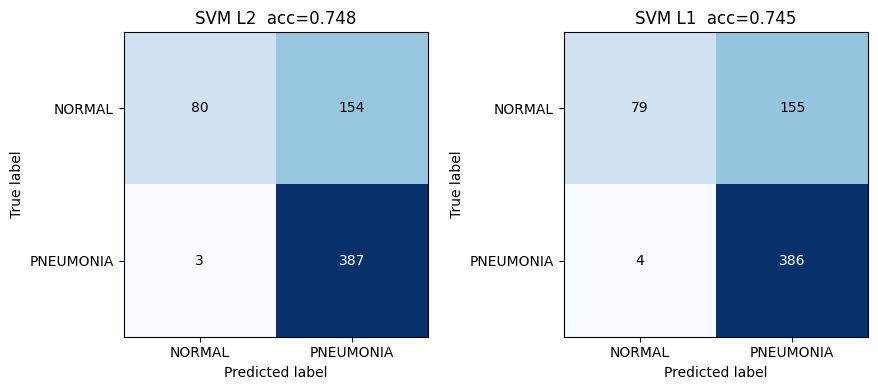

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (reg_type, (clf, _)) in zip(axes, results_reg.items()):
    y_pred_test = clf.predict(X_test)
    test_acc = metrics.accuracy(y_pred_test, y_test)
    cm = metrics.confusion_matrix(y_pred_test, y_test)
    report = metrics.per_class_report(y_pred_test, y_test)
    metrics.plot_confusion_matrix(cm, title=f'SVM {reg_type.upper()}  acc={test_acc:.3f}', ax=ax)
    print(f'SVM {reg_type.upper()}  test_acc={test_acc:.4f}')
    for cls, vals in report.items():
        print(f'  {cls}: precision={vals["precision"]:.3f}  recall={vals["recall"]:.3f}  f1={vals["f1"]:.3f}')
    print()
plt.tight_layout()
plt.show()

### 4.6 Two-layer CNN — Overfit sanity check

In [11]:
import torch
import torch.nn as nn
import solver
from conv_nets import TwoLayerConvNet

device = solver.get_device()
print('Training device:', device)

CNN_IMG_SIZE = 128

# Compute normalization stats from the training split.
print('Computing training mean/std...', end=' ', flush=True)
cnn_mean, cnn_std = du.compute_mean_std(train_items, image_size=CNN_IMG_SIZE)
print(f'mean={cnn_mean:.4f}  std={cnn_std:.4f}')

# Verify that TwoLayerConvNet can memorize a tiny batch (gradient flow check).
tiny_items = train_items[:32]
tiny_loader, _, _, _ = du.make_dataloaders(
    tiny_items, tiny_items, tiny_items,
    image_size=CNN_IMG_SIZE, batch_size=16, mean=cnn_mean, std=cnn_std, augment_train=False
)
sanity_model = TwoLayerConvNet(img_size=CNN_IMG_SIZE, num_filters=16, hidden_dim=128)
sanity_opt   = torch.optim.Adam(sanity_model.parameters(), lr=3e-3)
sanity_hist  = solver.train_model(
    sanity_model, tiny_loader, tiny_loader, nn.CrossEntropyLoss(),
    sanity_opt, device, num_epochs=40, verbose=False
)
final_train_acc = sanity_hist['train_acc'][-1]
print(f'Overfit check — final train_acc on 32-sample batch: {final_train_acc:.4f}')
assert final_train_acc > 0.95, 'Sanity check failed: network cannot memorize a tiny batch'
print('Sanity check passed.')

Training device: cuda
Computing training mean/std... mean=0.4849  std=0.2361
Overfit check — final train_acc on 32-sample batch: 1.0000
Sanity check passed.


### 4.7 Two-layer CNN — Full training

In [12]:
# Build full DataLoaders for CNN training.
train_loader, val_loader, test_loader, _ = du.make_dataloaders(
    train_items, val_items, test_items,
    image_size=CNN_IMG_SIZE, batch_size=64,
    mean=cnn_mean, std=cnn_std, augment_train=True
)

two_layer_net = TwoLayerConvNet(img_size=CNN_IMG_SIZE, num_filters=16, hidden_dim=256)
two_layer_opt = torch.optim.Adam(two_layer_net.parameters(), lr=1e-3, weight_decay=1e-4)

print('Training TwoLayerConvNet...')
two_layer_history = solver.train_model(
    two_layer_net, train_loader, val_loader,
    nn.CrossEntropyLoss(), two_layer_opt, device,
    num_epochs=20, verbose=True
)

Training TwoLayerConvNet...
epoch  1/20  loss 0.0883  train_acc 0.8836  val_acc 0.8274
epoch  2/20  loss 0.3575  train_acc 0.9136  val_acc 0.8312
epoch  3/20  loss 0.0747  train_acc 0.9529  val_acc 0.9079
epoch  4/20  loss 0.0836  train_acc 0.9348  val_acc 0.9488
epoch  5/20  loss 0.3458  train_acc 0.9461  val_acc 0.9476
epoch  6/20  loss 0.0181  train_acc 0.9179  val_acc 0.9591
epoch  7/20  loss 0.1172  train_acc 0.9364  val_acc 0.8568
epoch  8/20  loss 0.2352  train_acc 0.9596  val_acc 0.9412
epoch  9/20  loss 0.0500  train_acc 0.9542  val_acc 0.9079
epoch 10/20  loss 0.0333  train_acc 0.9619  val_acc 0.9207
epoch 11/20  loss 0.1410  train_acc 0.9497  val_acc 0.8760
epoch 12/20  loss 0.2290  train_acc 0.9461  val_acc 0.9476
epoch 13/20  loss 0.2254  train_acc 0.9608  val_acc 0.9297
epoch 14/20  loss 0.0382  train_acc 0.9614  val_acc 0.9079
epoch 15/20  loss 0.4725  train_acc 0.9556  val_acc 0.9552
epoch 16/20  loss 0.1371  train_acc 0.9619  val_acc 0.8977
epoch 17/20  loss 0.0599  tr

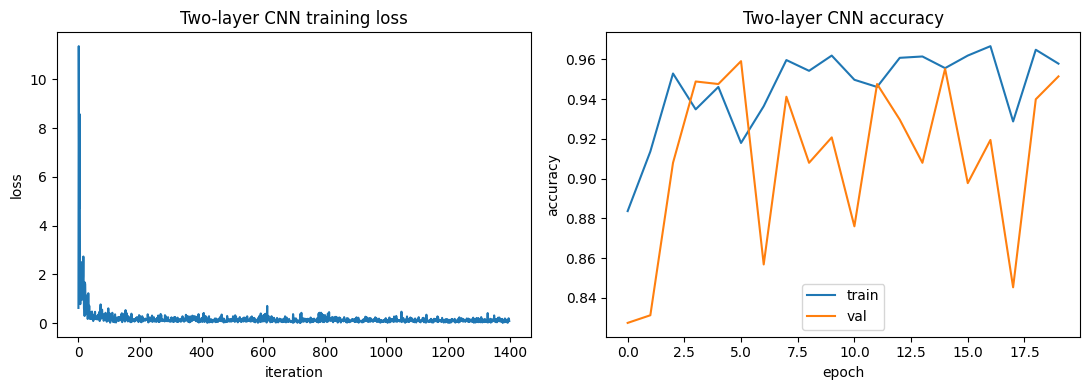


Two-layer CNN test accuracy: 0.8670
  NORMAL: precision=0.952  recall=0.679  f1=0.793
  PNEUMONIA: precision=0.836  recall=0.979  f1=0.902


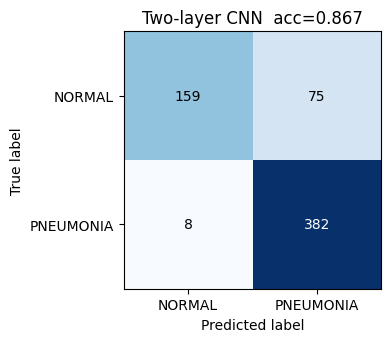

In [13]:
fig = metrics.plot_training_curves(two_layer_history, title_prefix='Two-layer CNN')
plt.show()

y_pred_2l, y_true_2l = solver.predict_all(two_layer_net, test_loader, device)
two_layer_acc = metrics.accuracy(y_pred_2l, y_true_2l)
print(f'\nTwo-layer CNN test accuracy: {two_layer_acc:.4f}')

report_2l = metrics.per_class_report(y_pred_2l, y_true_2l)
for cls, vals in report_2l.items():
    print(f'  {cls}: precision={vals["precision"]:.3f}  recall={vals["recall"]:.3f}  f1={vals["f1"]:.3f}')

fig2, ax2 = plt.subplots(figsize=(4, 4))
metrics.plot_confusion_matrix(metrics.confusion_matrix(y_pred_2l, y_true_2l),
                               title=f'Two-layer CNN  acc={two_layer_acc:.3f}', ax=ax2)
plt.tight_layout()
plt.show()

### 4.8 Deep CNN — Overfit sanity check

In [14]:
from conv_nets import DeepConvNet

# Sanity check: DeepConvNet should memorize a small batch.
sanity_deep = DeepConvNet(channels=(16, 32, 64), dropout=0.0)
sanity_deep_opt = torch.optim.Adam(sanity_deep.parameters(), lr=2e-3)
sanity_deep_hist = solver.train_model(
    sanity_deep, tiny_loader, tiny_loader, nn.CrossEntropyLoss(),
    sanity_deep_opt, device, num_epochs=30, verbose=False
)
final_acc_deep = sanity_deep_hist['train_acc'][-1]
print(f'DeepConvNet overfit check — train_acc: {final_acc_deep:.4f}')
assert final_acc_deep > 0.95, 'Deep net sanity check failed'
print('Sanity check passed.')

DeepConvNet overfit check — train_acc: 1.0000
Sanity check passed.


### 4.9 Deep CNN — Full training with class-weighted loss

In [15]:
import torch

# Build class-weighted loss to account for the 1:2.9 NORMAL/PNEUMONIA imbalance.
class_weights = du.compute_class_weights(train_items)
print('Class weights (NORMAL, PNEUMONIA):', class_weights)
weighted_criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights).to(device)
)

deep_net = DeepConvNet(channels=(32, 64, 128), hidden_dim=256, dropout=0.5)
deep_opt = torch.optim.Adam(deep_net.parameters(), lr=1e-3, weight_decay=1e-4)

print('Training DeepConvNet...')
deep_history = solver.train_model(
    deep_net, train_loader, val_loader,
    weighted_criterion, deep_opt, device,
    num_epochs=30, verbose=True
)

Class weights (NORMAL, PNEUMONIA): [1.9447368 0.6730419]
Training DeepConvNet...
epoch  1/30  loss 0.2065  train_acc 0.9188  val_acc 0.8376
epoch  2/30  loss 0.0234  train_acc 0.9204  val_acc 0.8146
epoch  3/30  loss 0.0284  train_acc 0.9111  val_acc 0.8210
epoch  4/30  loss 0.0479  train_acc 0.9549  val_acc 0.9066
epoch  5/30  loss 0.0735  train_acc 0.9569  val_acc 0.9527
epoch  6/30  loss 0.1355  train_acc 0.9319  val_acc 0.9565
epoch  7/30  loss 0.0150  train_acc 0.9657  val_acc 0.9322
epoch  8/30  loss 0.0335  train_acc 0.9378  val_acc 0.8299
epoch  9/30  loss 0.0925  train_acc 0.9657  val_acc 0.9156
epoch 10/30  loss 0.1244  train_acc 0.9668  val_acc 0.9425
epoch 11/30  loss 0.1210  train_acc 0.9680  val_acc 0.9207
epoch 12/30  loss 0.1282  train_acc 0.9680  val_acc 0.9169
epoch 13/30  loss 0.2609  train_acc 0.9184  val_acc 0.7698
epoch 14/30  loss 0.2881  train_acc 0.9626  val_acc 0.8862
epoch 15/30  loss 0.0058  train_acc 0.9720  val_acc 0.9309
epoch 16/30  loss 0.0259  train_ac

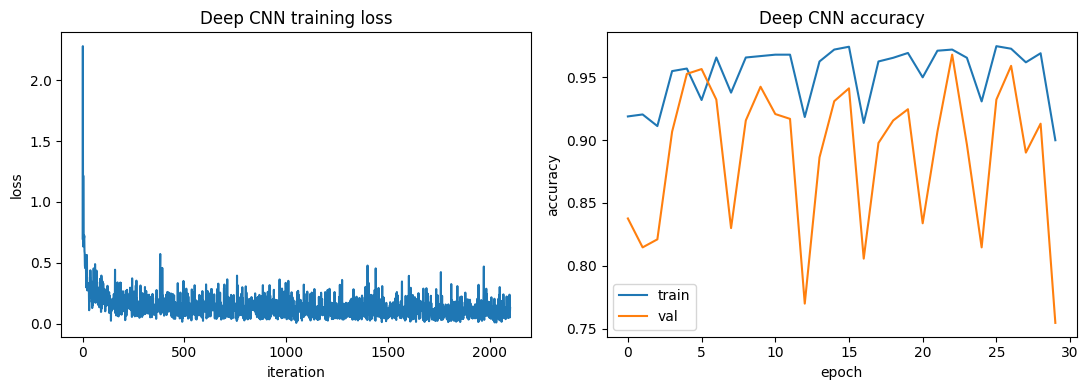


Deep CNN test accuracy: 0.8237
  NORMAL: precision=0.695  recall=0.944  f1=0.801
  PNEUMONIA: precision=0.958  recall=0.751  f1=0.842


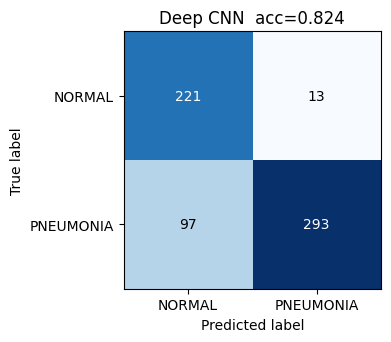

In [16]:
fig = metrics.plot_training_curves(deep_history, title_prefix='Deep CNN')
plt.show()

y_pred_deep, y_true_deep = solver.predict_all(deep_net, test_loader, device)
deep_acc = metrics.accuracy(y_pred_deep, y_true_deep)
print(f'\nDeep CNN test accuracy: {deep_acc:.4f}')

report_deep = metrics.per_class_report(y_pred_deep, y_true_deep)
for cls, vals in report_deep.items():
    print(f'  {cls}: precision={vals["precision"]:.3f}  recall={vals["recall"]:.3f}  f1={vals["f1"]:.3f}')

fig3, ax3 = plt.subplots(figsize=(4, 4))
metrics.plot_confusion_matrix(metrics.confusion_matrix(y_pred_deep, y_true_deep),
                               title=f'Deep CNN  acc={deep_acc:.3f}', ax=ax3)
plt.tight_layout()
plt.show()

### 4.10 Model comparison summary

In [17]:
# Collect test accuracy and pneumonia recall for each model.
svm_l2_clf, _ = results_reg['l2']
svm_l2_pred   = svm_l2_clf.predict(X_test)
svm_l2_acc    = metrics.accuracy(svm_l2_pred, y_test)
svm_l2_recall = metrics.per_class_report(svm_l2_pred, y_test)['PNEUMONIA']['recall']

tl_recall = report_2l['PNEUMONIA']['recall']
dp_recall = report_deep['PNEUMONIA']['recall']

print(f'{"Model":<22} {"Test Acc":>10} {"Pneu Recall":>12}')
print('-' * 46)
print(f'{"Linear SVM (L2)":<22} {svm_l2_acc:>10.4f} {svm_l2_recall:>12.4f}')
print(f'{"Two-layer CNN":<22} {two_layer_acc:>10.4f} {tl_recall:>12.4f}')
print(f'{"Deep CNN":<22} {deep_acc:>10.4f} {dp_recall:>12.4f}')

Model                    Test Acc  Pneu Recall
----------------------------------------------
Linear SVM (L2)            0.7484       0.9923
Two-layer CNN              0.8670       0.9795
Deep CNN                   0.8237       0.7513


---

## 5. Conclusion / Future Work

We built a complete end-to-end pipeline for binary pneumonia detection from chest X-rays, progressing from a linear SVM baseline through a two-layer convolutional network to a deeper architecture with batch normalization and class-weighted loss. The final test results across all three models are:

| Model | Test Accuracy | NORMAL Recall | PNEUMONIA Recall |
|-------|--------------|--------------|-----------------|
| Linear SVM (L2) | 74.8 % | 34.2 % | 99.2 % |
| Linear SVM (L1) | 74.5 % | 33.8 % | 99.0 % |
| Two-layer CNN | **86.7 %** | 67.9 % | **97.9 %** |
| Deep CNN (class-weighted) | 82.4 % | **94.4 %** | 75.1 % |

**What we learned:**

The linear SVM result is instructive: its 74.8 % test accuracy is inflated by the class imbalance. With a NORMAL recall of only 34 %, the model nearly always predicts PNEUMONIA regardless of the actual image content — a degenerate strategy that happens to look reasonable on an unbalanced test set. L1 and L2 regularization produce essentially identical results (74.8 % vs 74.5 %), confirming that the bottleneck is representational capacity, not overfitting. Notably, val accuracy reached 95.9 % during the hyperparameter sweep while test accuracy sat at 74.8 %, exposing a distribution gap between the re-split validation set (25.7 % NORMAL) and the original test set (37.5 % NORMAL).

The two-layer CNN delivers the largest single accuracy jump (+11.9 % over SVM). Even a single convolutional stage is enough to move from near-degenerate pixel correlations to genuine texture features, nearly doubling NORMAL recall (34 % → 68 %) while keeping PNEUMONIA recall above 97 %. This is the strongest model for raw screening accuracy.

The deep CNN produces a surprising result: lower overall accuracy (82.4 %) than the two-layer CNN (86.7 %), yet dramatically better NORMAL recall (94.4 % vs 67.9 %). This is a direct consequence of the class-weighted loss, which penalises NORMAL misclassifications 2.9× more heavily and shifts the decision boundary away from the majority class. From a clinical standpoint the tradeoff is meaningful: the deep CNN avoids incorrectly clearing 94 of every 100 healthy patients, at the cost of missing roughly 25 % of pneumonia cases. Which model is preferable depends on the deployment context — a first-line mass screening tool should minimise missed pneumonia (favouring the two-layer CNN), whereas a secondary filter designed to reduce unnecessary antibiotic prescriptions benefits from higher NORMAL recall (favouring the deep CNN).

The validation loss curves for both CNNs oscillate significantly across epochs, a side effect of the relatively small 782-image validation set. More stable training signals would require either a larger dataset or k-fold cross-validation.

**Limitations:**

- Our architectures are trained from scratch at 128 × 128 resolution for a modest number of epochs. Transfer learning from an ImageNet-pretrained backbone (e.g. ResNet18) would very likely exceed our best model with far fewer training iterations and without needing to design the architecture manually.
- The binary PNEUMONIA label conflates bacterial and viral pneumonia, which present with different radiographic patterns and require different treatments. A three-class formulation (NORMAL / bacterial / viral) would be clinically more actionable.
- The dataset originates from a single pediatric hospital in Guangzhou, so generalisation to adult patients or different imaging equipment is not guaranteed.

**Future work:**

- Apply LoRA-style low-rank adaptation of a pretrained backbone for sample-efficient fine-tuning.
- Investigate GradCAM attribution maps to visualise which lung regions drive each prediction, making the model more interpretable to clinicians.
- Experiment with test-time augmentation (averaging predictions over several augmented views) to improve robustness without additional training.
- Extend the label set to distinguish bacterial from viral pneumonia for clinically actionable predictions.